In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("data/raw.csv")

In [3]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.duplicated().sum() 

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [9]:
df["gender"].unique()

array(['female', 'male'], dtype=object)

In [10]:
numeric_feature=[feature for feature in df.columns if df[feature].dtype !='O']
cat_feature=[feature for feature in df.columns if df[feature].dtype =='O']

print("we have {} numerical feature : {}".format(len(numeric_feature),numeric_feature))
print("we have {} catfeature : {}".format(len(cat_feature),cat_feature))


we have 3 numerical feature : ['math score', 'reading score', 'writing score']
we have 5 catfeature : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [11]:
df["total score"]=df["math score"]+df["reading score"]+df["writing score"]
df["avg"]=df["total score"]/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,avg
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [12]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'total score', 'avg'],
      dtype='object')

In [13]:
math_full=df[df["math score"]==100]["avg"].count()
writing_full=df[df["writing score"]==100]["avg"].count()
reading_full=df[df["reading score"]==100]["avg"].count()

print(f"number of students wit full marks in reading: {reading_full} ")
print(f"number of students wit full marks in math: {math_full} ")
print(f"number of students wit full marks in writing: {writing_full} ")



number of students wit full marks in reading: 17 
number of students wit full marks in math: 7 
number of students wit full marks in writing: 14 


In [14]:
reading_less=df[df["reading score"]<=20]["avg"].count()
math_less=df[df["math score"]<=20]["avg"].count()
writing_less=df[df["writing score"]<=20]["avg"].count()
print(f"number of student with less than 20 in math: {math_less}")
print(f"number of student with less than 20 in reading: {reading_less}")
print(f"number of student with less than 20 in writing: {writing_less}")





number of student with less than 20 in math: 4
number of student with less than 20 in reading: 1
number of student with less than 20 in writing: 3


<Axes: xlabel='avg', ylabel='Count'>

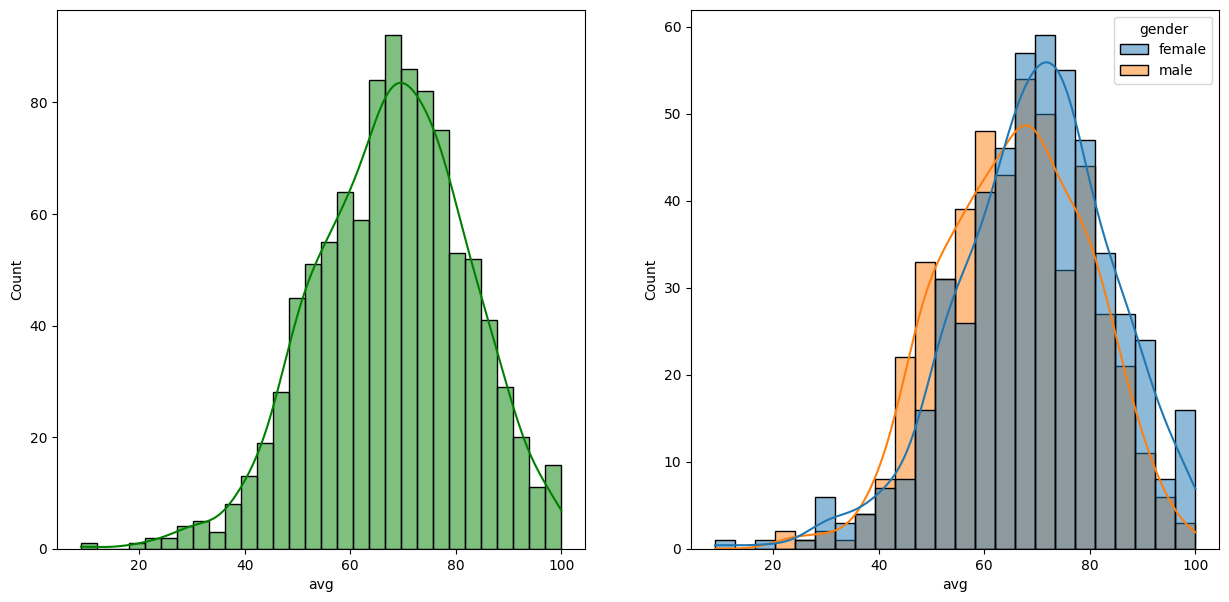

In [15]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='avg',bins=30,kde=True,color="g")
plt.subplot(122)
sns.histplot(data=df,x='avg',hue="gender",kde=True)



<Axes: xlabel='total score', ylabel='Count'>

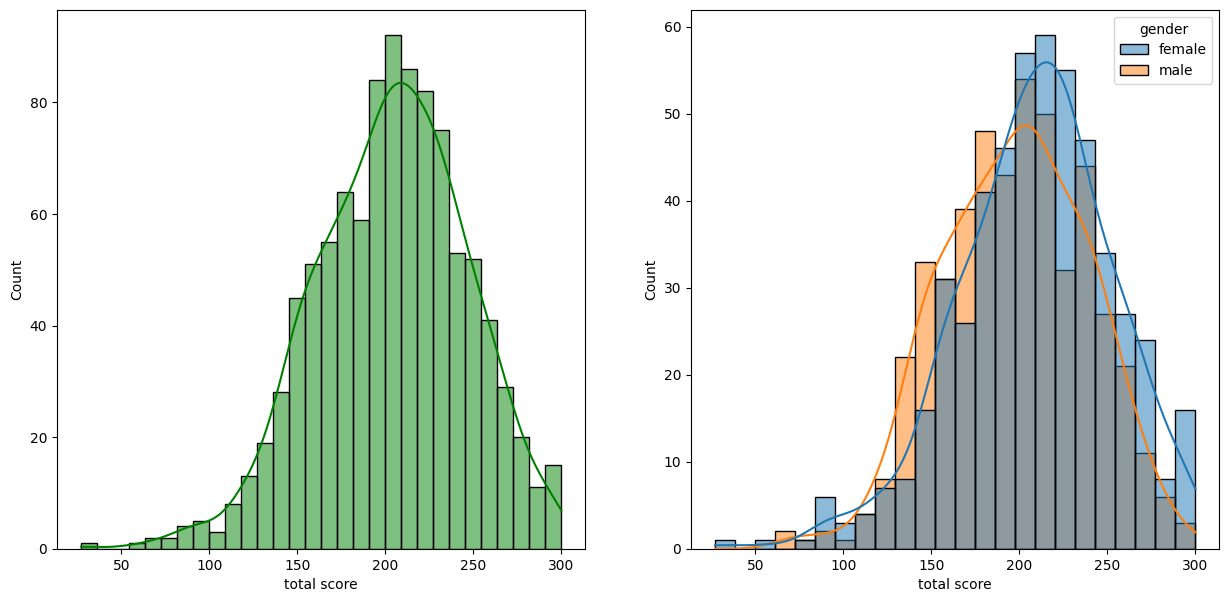

In [16]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color="g")
plt.subplot(122)
sns.histplot(data=df,x='total score',hue="gender",kde=True)

<Axes: xlabel='avg', ylabel='Count'>

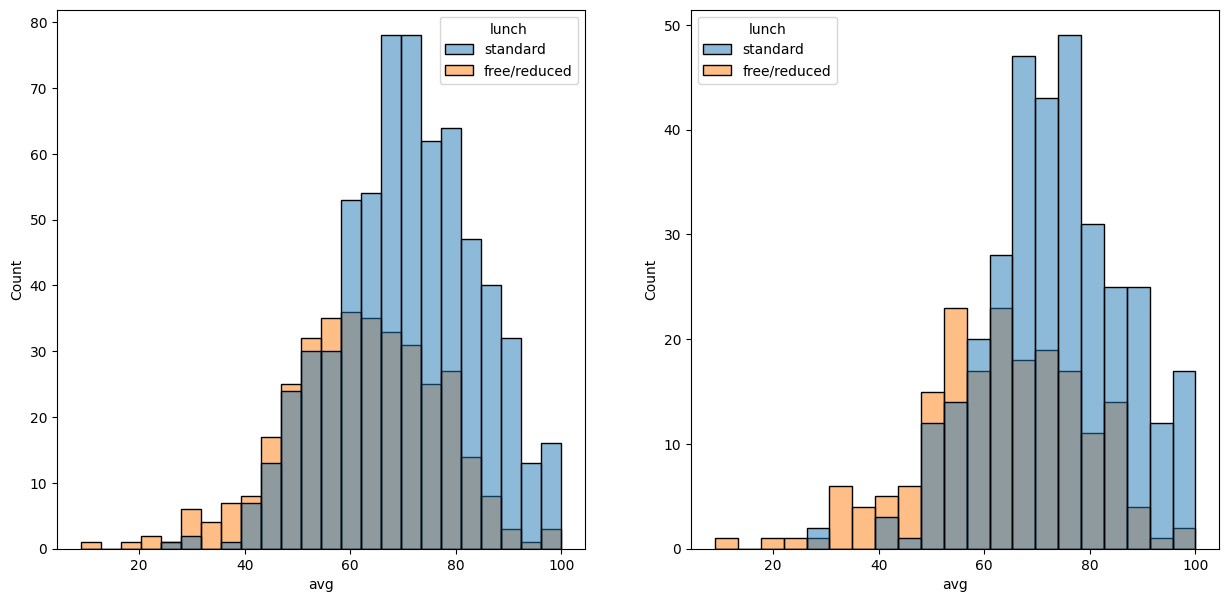

In [17]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x="avg",hue="lunch")
plt.subplot(122)
sns.histplot(data=df[df.gender=="female"],x="avg",hue="lunch")

In [18]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,avg
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


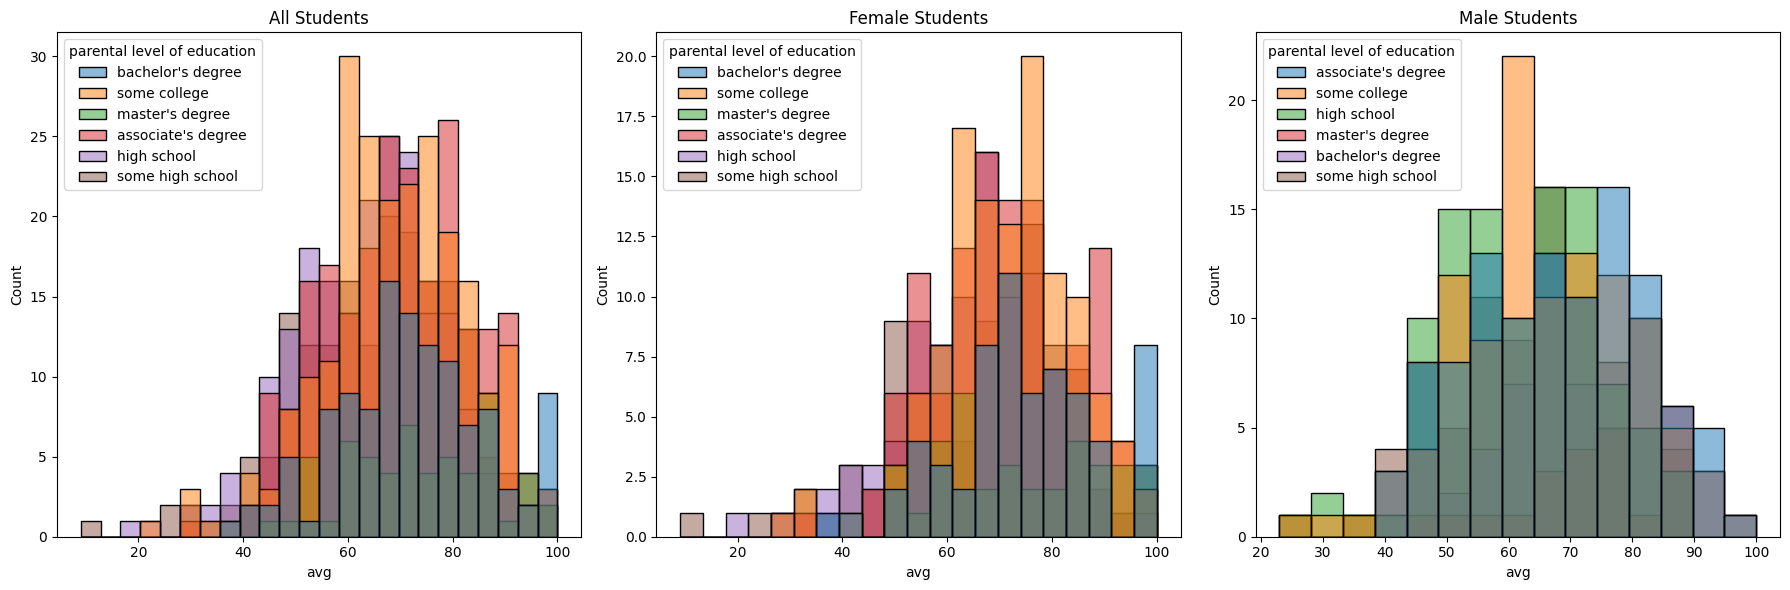

In [19]:
plt.figure(figsize=(18, 6))  # Start a fresh figure

plt.subplot(1, 3, 1)
sns.histplot(data=df, x="avg", hue="parental level of education")
plt.title("All Students")

plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == "female"], x="avg", hue="parental level of education")
plt.title("Female Students")

plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == "male"], x="avg", hue="parental level of education")
plt.title("Male Students")

plt.tight_layout()
plt.show()


C:\Users\hkoli\AppData\Local\Temp\ipykernel_11572\2952756454.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["gender"],data=df,palette="bright",ax=ax[0])


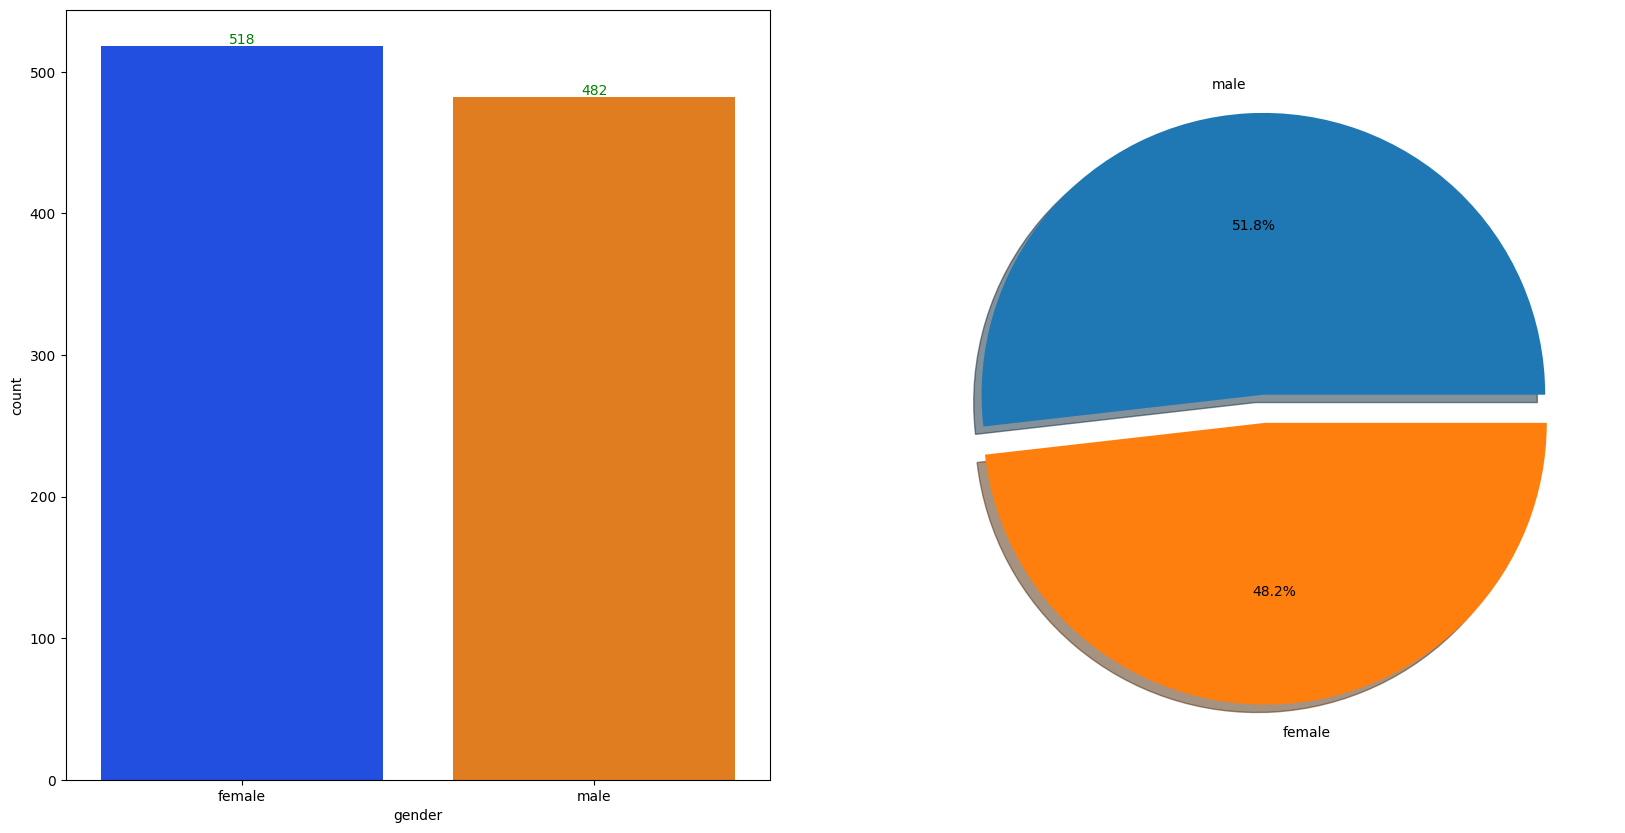

In [20]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df["gender"],data=df,palette="bright",ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container,color="green")
plt.pie(x=df["gender"].value_counts(),labels=["male","female"],explode=[0,0.1],shadow=True,autopct='%1.1f%%')
plt.show()

In [21]:
groupby=df.groupby("gender")["total score"].sum()
groupby

gender
female    108111
male       95201
Name: total score, dtype: int64

In [22]:
value_count=df["parental level of education"].value_counts()
value_count

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

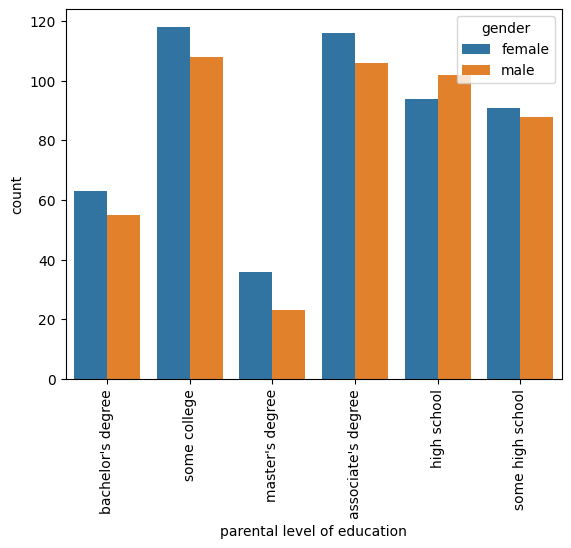

In [23]:
sns.countplot(data=df,x="parental level of education",hue="gender")
plt.xticks(rotation=90)
plt.show()